In [1]:
# ── Librairies ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style global ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Librairies chargées avec succès")

✅ Librairies chargées avec succès


In [2]:
# ── Montage Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Chargement des données ─────────────────────────────────────────────────────
path = '/content/drive/MyDrive/GiveMeSomeCredit/'

train = pd.read_csv(path + 'cs-training.csv')
test  = pd.read_csv(path + 'cs-test.csv')

print(f"Train : {train.shape[0]:,} lignes × {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes  × {test.shape[1]} colonnes")

Train : 150,000 lignes × 12 colonnes
Test  : 101,503 lignes  × 12 colonnes


In [4]:
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing,
    'Pourcentage (%)' : missing_pct
}).sort_values('Pourcentage (%)', ascending=False)

missing_df[missing_df['Valeurs manquantes'] > 0]

,Valeurs manquantes,Pourcentage (%)
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


## Traitement des valeurs manquantes

Deux colonnes contiennent des valeurs manquantes :
- **MonthlyIncome** : 29,731 manquants (20%) — significatif
- **NumberOfDependents** : 3,924 manquants (2.6%) — faible

### Approche retenue

Pour `MonthlyIncome`, on applique une **double stratégie** :
1. On crée une variable indicatrice `MonthlyIncome_missing` (1 si manquant, 0 sinon) — car le fait de ne pas déclarer son revenu est en soi une information sur le risque du client
2. On impute les valeurs manquantes par la **médiane** — plus robuste que la moyenne face aux valeurs extrêmes (max observé : 3,008,750$), et plus honnête que 0 qui supposerait un revenu nul

Pour `NumberOfDependents`, on impute directement par la médiane (taux de manquants trop faible pour justifier un indicateur).

### Règle fondamentale — pas de data leakage

La médiane est calculée **uniquement sur le jeu d'entraînement** et appliquée ensuite au jeu de test.  
En pratique bancaire, quand un nouveau client arrive, on ne recalcule pas la médiane sur ses données — on utilise celle apprise sur l'historique.

In [7]:
# ── Traitement des valeurs manquantes ──────────────────────────────────────────

# 1. Supprimer la colonne index inutile
train.drop(columns=['Unnamed: 0'], inplace=True)
test.drop(columns=['Unnamed: 0'], inplace=True)

# 2. Indicateur de manquant pour MonthlyIncome
train['MonthlyIncome_missing'] = train['MonthlyIncome'].isnull().astype(int)
test['MonthlyIncome_missing']  = test['MonthlyIncome'].isnull().astype(int)

# 3. Imputation par la médiane du train uniquement
median_income     = train['MonthlyIncome'].median()
median_dependents = train['NumberOfDependents'].median()

train['MonthlyIncome'].fillna(median_income, inplace=True)
test['MonthlyIncome'].fillna(median_income, inplace=True)        # médiane du train appliquée au test

train['NumberOfDependents'].fillna(median_dependents, inplace=True)
test['NumberOfDependents'].fillna(median_dependents, inplace=True)  # médiane du train appliquée au test

# 4. Vérification
print(f"Médiane MonthlyIncome utilisée      : {median_income:,.0f} $")
print(f"Médiane NumberOfDependents utilisée : {median_dependents:.0f}")
print(f"\nValeurs manquantes train restantes  : {train.isnull().sum().sum()}")
print(f"Valeurs manquantes test restantes   : {test.isnull().sum().sum()}")

Médiane MonthlyIncome utilisée      : 5,400 $
Médiane NumberOfDependents utilisée : 0

Valeurs manquantes train restantes  : 0
Valeurs manquantes test restantes   : 101503


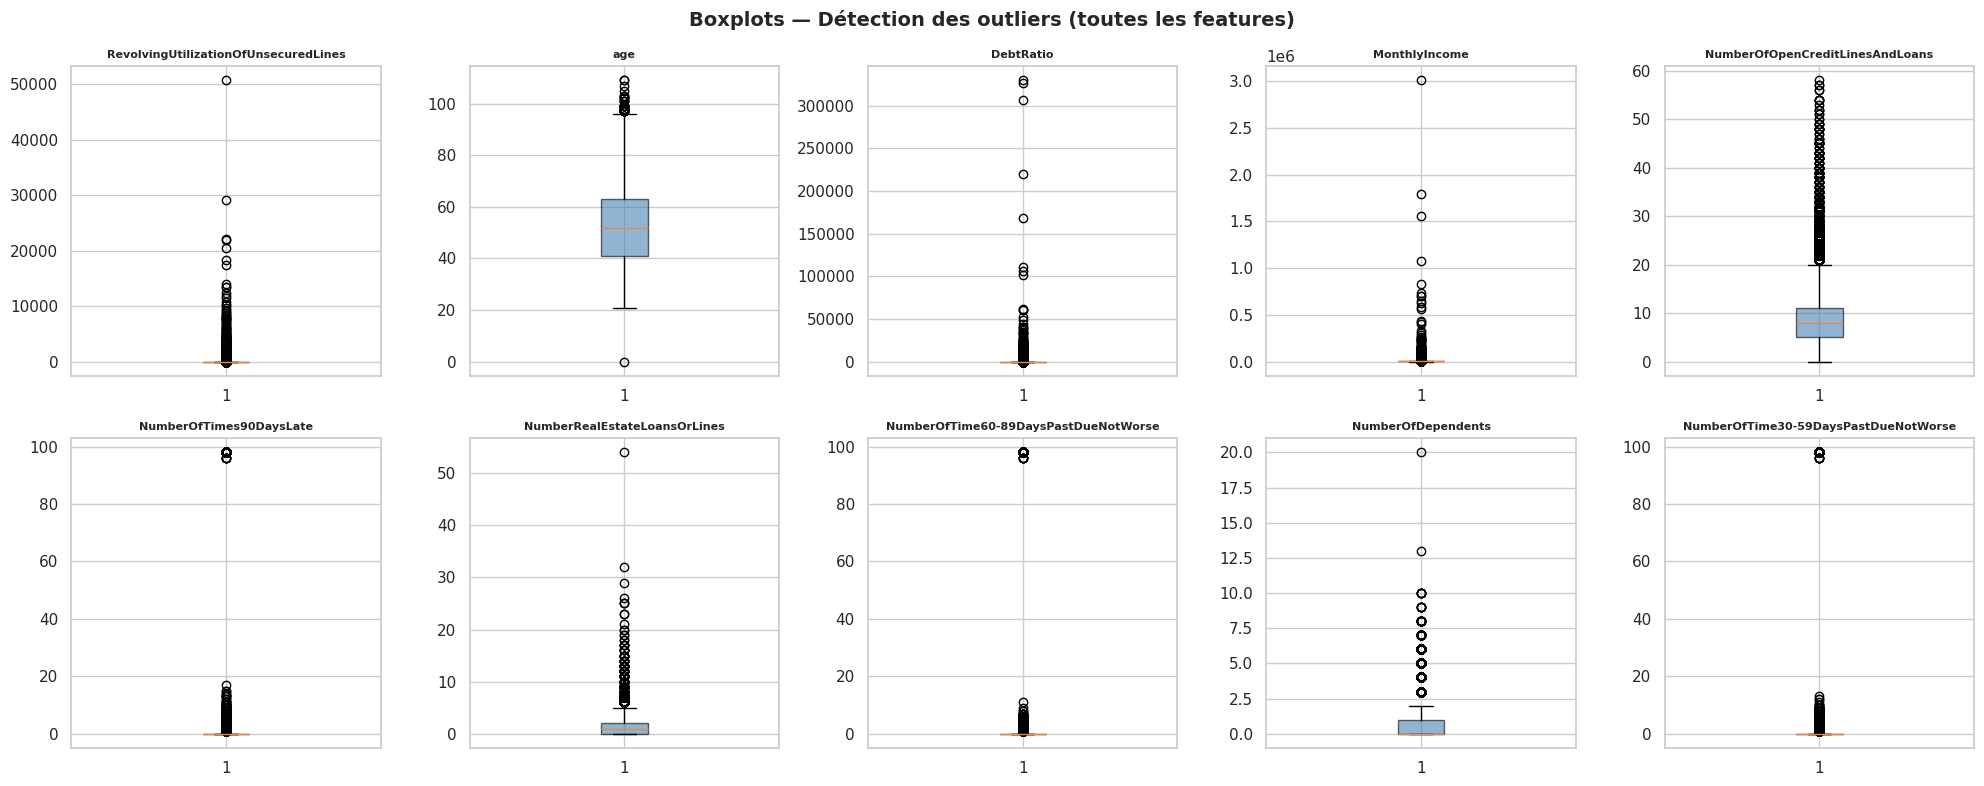

In [8]:
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
    'NumberOfTime30-59DaysPastDueNotWorse'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(train[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle("Boxplots — Détection des outliers (toutes les features)",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

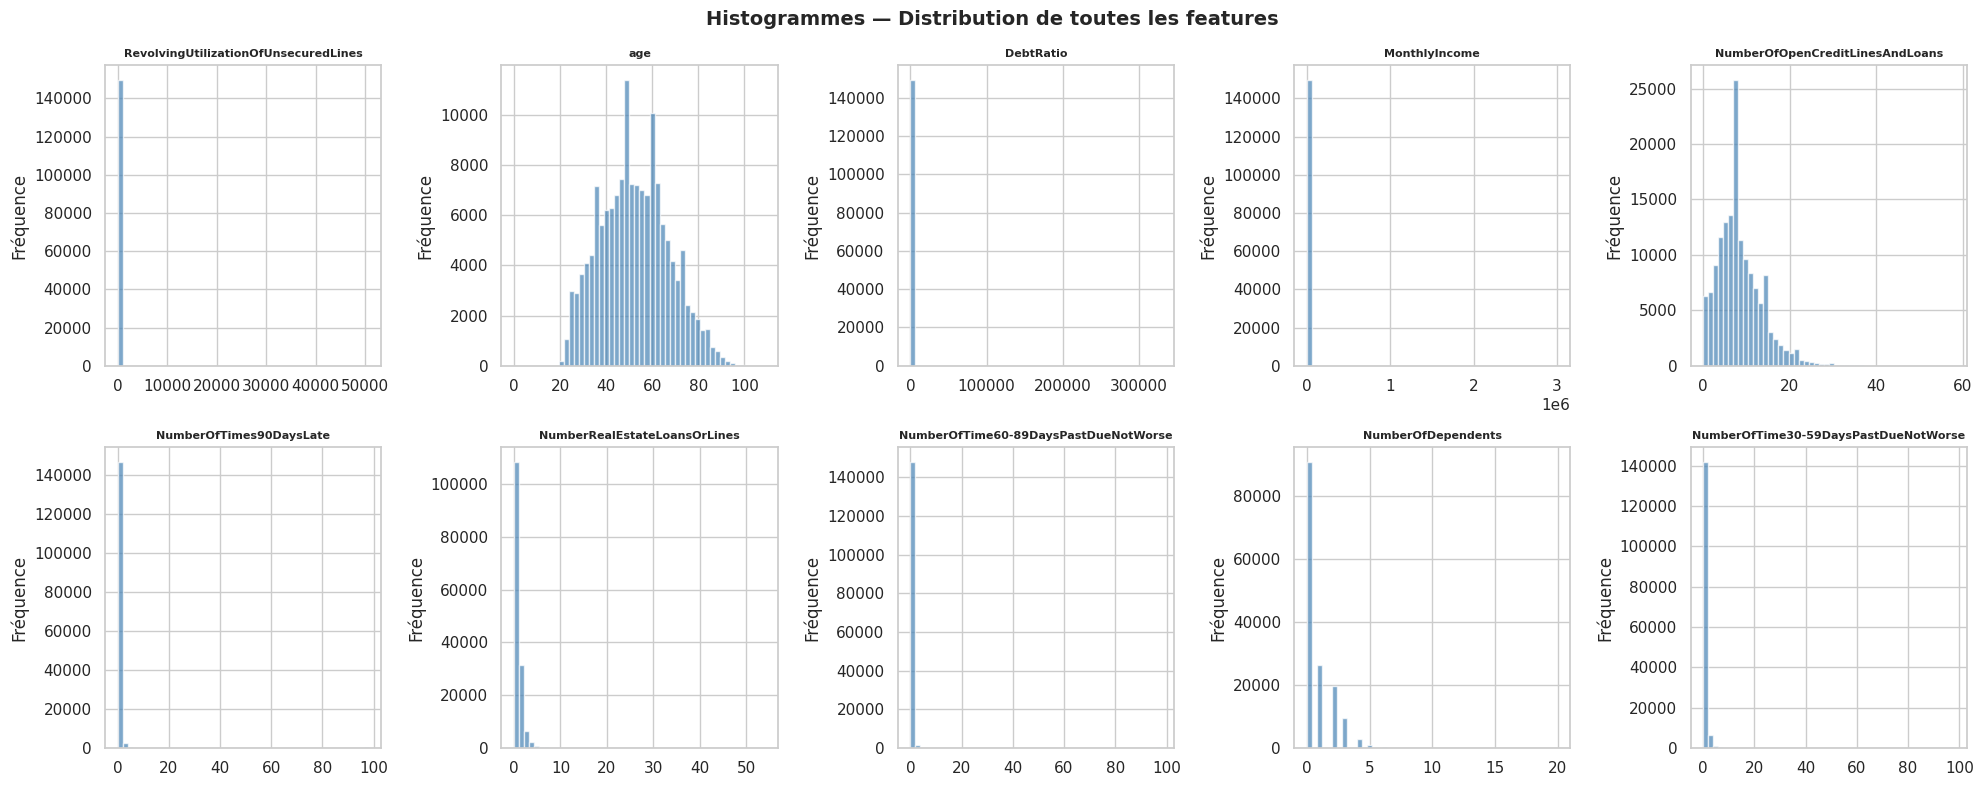

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(train[col].dropna(), bins=50,
                 color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Histogrammes — Distribution de toutes les features",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('histogrammes_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Traitement des outliers ────────────────────────────────────────────────────

# 1. age = 0 → erreur de saisie, on supprime la ligne
train = train[train['age'] > 0]
test  = test[test['age'] > 0]

# 2. Codes d'erreur 96 et 98 dans les colonnes de retard → remplacer par NaN puis imputer
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in past_due_cols:
    # Remplacer 96 et 98 par NaN
    train[col] = train[col].replace({96: np.nan, 98: np.nan})
    test[col]  = test[col].replace({96: np.nan, 98: np.nan})

    # Imputer par la médiane du train
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)

# 3. RevolvingUtilization et DebtRatio → capiter à 1
train['RevolvingUtilizationOfUnsecuredLines'] = train['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)
test['RevolvingUtilizationOfUnsecuredLines']  = test['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)

train['DebtRatio'] = train['DebtRatio'].clip(upper=1)
test['DebtRatio']  = test['DebtRatio'].clip(upper=1)

# 4. MonthlyIncome → capiter au 99ème percentile du train
income_cap = train['MonthlyIncome'].quantile(0.99)
train['MonthlyIncome'] = train['MonthlyIncome'].clip(upper=income_cap)
test['MonthlyIncome']  = test['MonthlyIncome'].clip(upper=income_cap)

# 5. Vérification
print(f"Taille train après nettoyage : {train.shape}")
print(f"Taille test après nettoyage  : {test.shape}")
print(f"\nMax RevolvingUtilization : {train['RevolvingUtilizationOfUnsecuredLines'].max():.2f}")
print(f"Max DebtRatio            : {train['DebtRatio'].max():.2f}")
print(f"Max MonthlyIncome        : {train['MonthlyIncome'].max():,.0f} $")

Taille train après nettoyage : (149999, 12)
Taille test après nettoyage  : (101503, 12)

Max RevolvingUtilization : 1.00
Max DebtRatio            : 1.00
Max MonthlyIncome        : 23,000 $


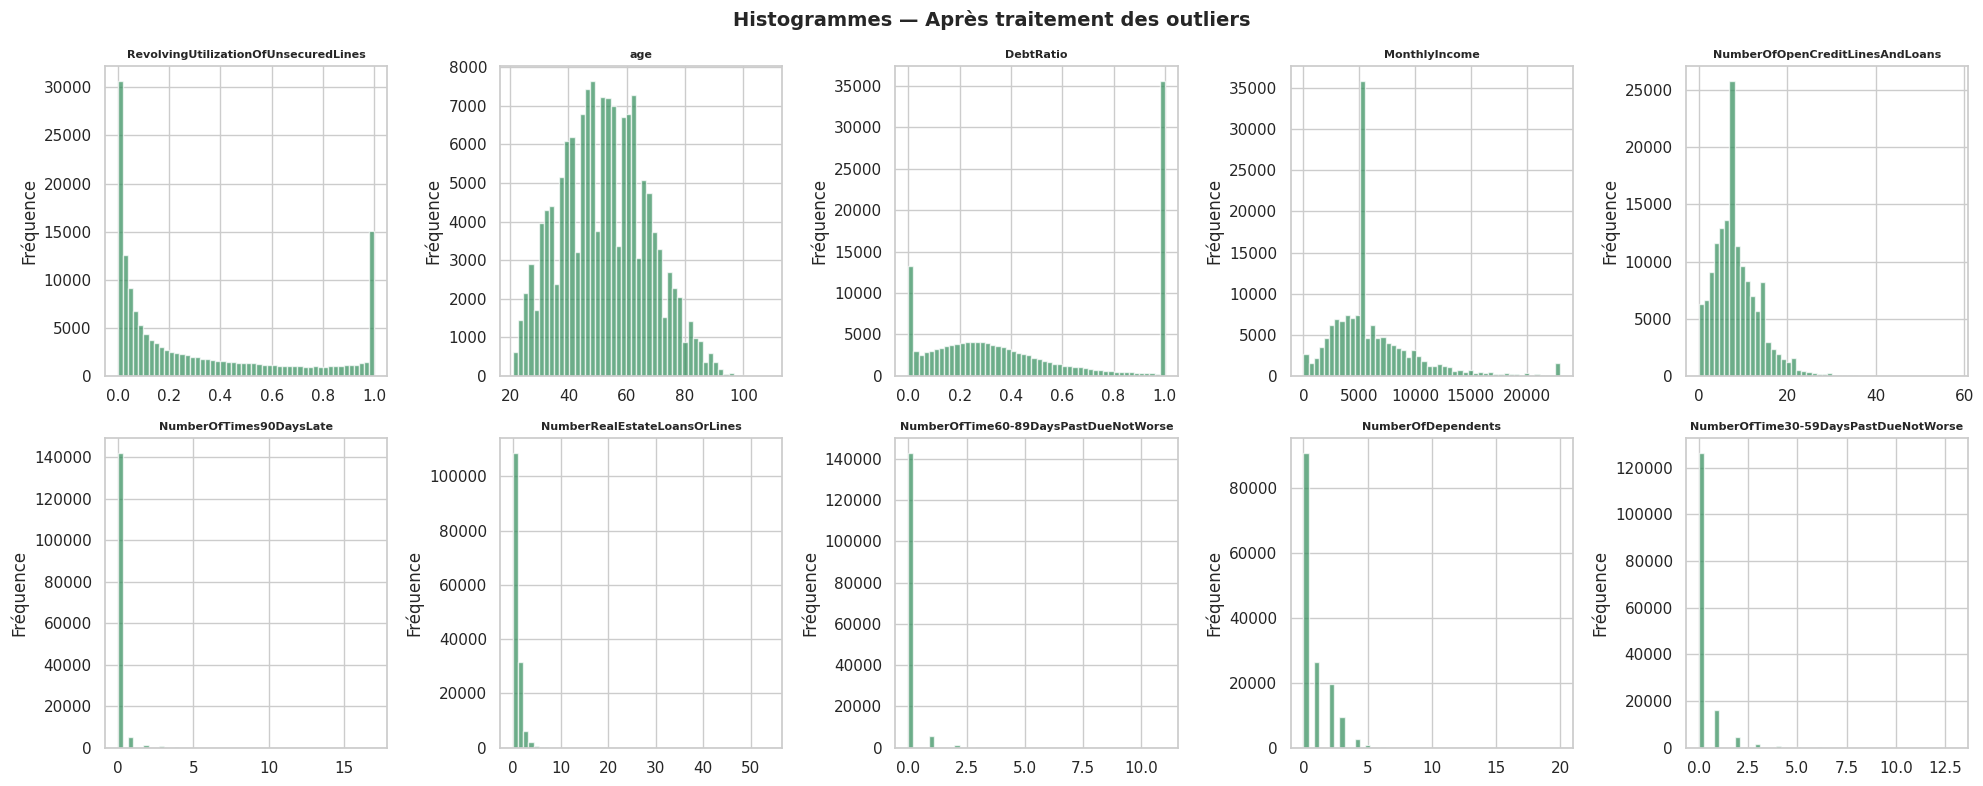

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(train[col].dropna(), bins=50,
                 color='seagreen', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_ylabel('Fréquence')

plt.suptitle("Histogrammes — Après traitement des outliers",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('histogrammes_apres_nettoyage.png', dpi=150, bbox_inches='tight')
plt.show()

## Traitement des outliers

L'analyse des boxplots et histogrammes a révélé 4 types d'anomalies :

| Variable | Problème détecté | Technique appliquée |
|---|---|---|
| `age` | 1 valeur = 0 (impossible) | Suppression de la ligne |
| `NumberOfTime30-59...`, `90DaysLate`, `60-89...` | Valeurs 96 et 98 (codes sentinelles Kaggle) | Remplacement par NaN + imputation médiane du train |
| `DebtRatio`, `RevolvingUtilization` | Ratios > 1 (impossible par définition) | Capitage à 1 |
| `MonthlyIncome` | Valeurs extrêmes jusqu'à 3,000,000$ | Winsorization au 99ème percentile (23,000$) |

**Résultat** : train passe de 150,000 à 149,999 lignes.
Toutes les transformations sont calculées sur le train et appliquées au test.

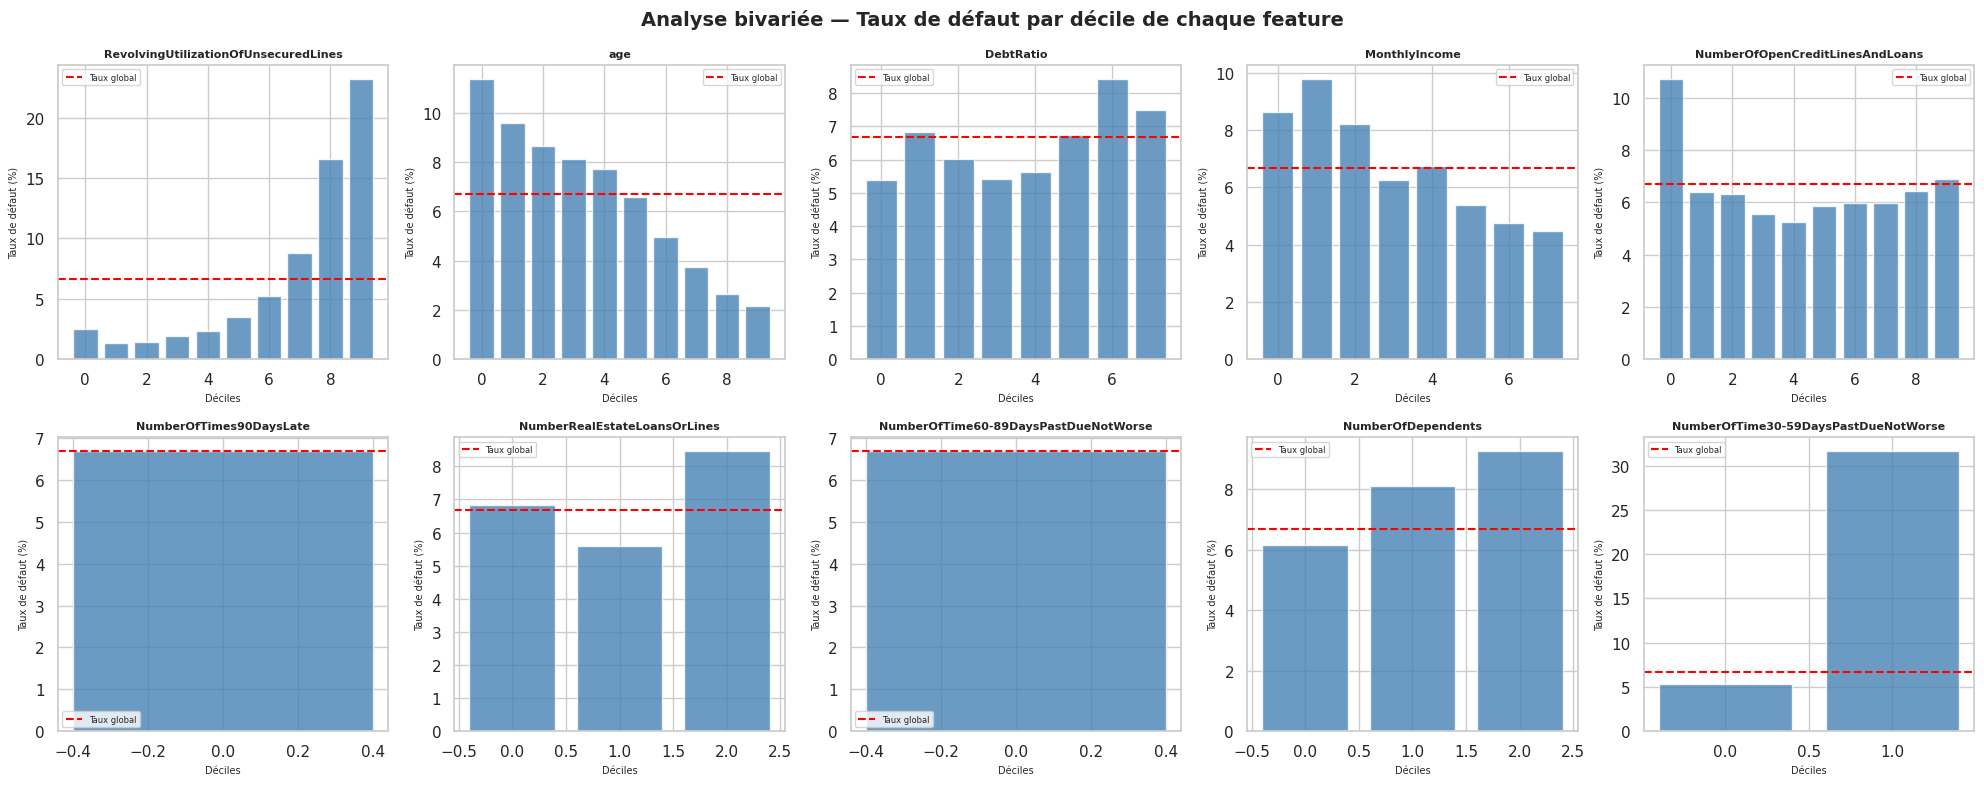

In [12]:
# ── Analyse bivariée — taux de défaut par feature ──────────────────────────────

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    # Découper la variable en 10 tranches égales
    train['bucket'] = pd.qcut(train[col], q=10, duplicates='drop')

    # Calculer le taux de défaut par tranche
    default_rate = train.groupby('bucket', observed=True)['SeriousDlqin2yrs'].mean() * 100

    # Tracer
    axes[i].bar(range(len(default_rate)), default_rate.values,
                color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axhline(y=train['SeriousDlqin2yrs'].mean()*100,
                    color='red', linestyle='--', linewidth=1.5, label='Taux global')
    axes[i].set_title(col, fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Déciles', fontsize=7)
    axes[i].set_ylabel('Taux de défaut (%)', fontsize=7)
    axes[i].legend(fontsize=6)

# Supprimer la colonne temporaire
train.drop(columns=['bucket'], inplace=True)

plt.suptitle("Analyse bivariée — Taux de défaut par décile de chaque feature",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('analyse_bivariee.png', dpi=150, bbox_inches='tight')
plt.show()

## Analyse bivariée — Taux de défaut par décile

Pour chaque feature, on a découpé les valeurs en 10 tranches égales (déciles)
et calculé le taux de défaut moyen dans chaque tranche.
La ligne rouge représente le taux de défaut global (6.68%).

**Interprétation : plus les barres s'éloignent de la ligne rouge,
plus la variable est discriminante.**

### Résultats par variable

| Variable | Observation | Pouvoir discriminant |
|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | Relation croissante forte — plus le crédit est utilisé, plus le risque augmente | ✅ Élevé |
| `age` | Relation décroissante — les jeunes sont plus risqués que les seniors | ✅ Élevé |
| `MonthlyIncome` | Relation décroissante — plus le revenu est élevé, moins le client fait défaut | ✅ Moyen-Élevé |
| `NumberOfTime30-59DaysPastDueNotWorse` | Dernier décile atteint 30% de défaut — signal très fort | ✅ Élevé |
| `DebtRatio` | Relation non monotone — signal moins clair | ⚠️ Faible |
| `NumberRealEstateLoansOrLines` | Barres proches de la ligne rouge | ⚠️ Faible |
| `NumberOfDependents` | Peu de variation autour du taux global | ⚠️ Faible |
| `NumberOfTimes90DaysLate` | Distribution très concentrée en 0 — manque de granularité | ⚠️ Limité |
| `NumberOfTime60-89DaysPastDueNotWorse` | Même problème que 90DaysLate | ⚠️ Limité |

### Conclusion

Les variables les plus prometteuses pour la modélisation PD sont :
`RevolvingUtilizationOfUnsecuredLines`, `age`, `MonthlyIncome`,
et `NumberOfTime30-59DaysPastDueNotWorse`.

Ces observations seront confirmées formellement par le calcul de
l'**Information Value (IV)** en Phase 2.

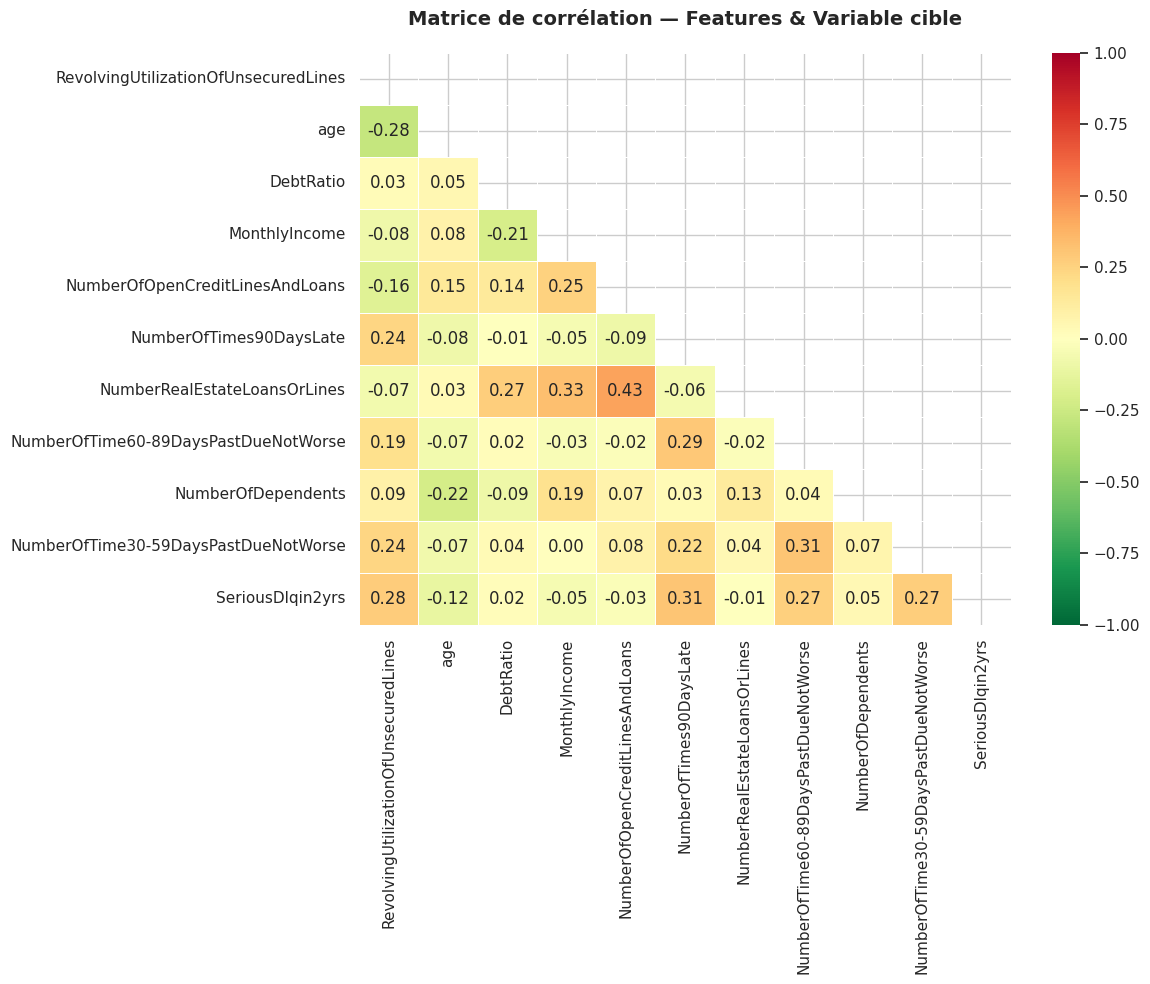

In [13]:
# ── Matrice de corrélation ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 10))

corr_matrix = train[features + ['SeriousDlqin2yrs']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn_r',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)

ax.set_title("Matrice de corrélation — Features & Variable cible",
             fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Matrice de corrélation

### Corrélations avec la variable cible
Les variables les plus corrélées avec `SeriousDlqin2yrs` sont :
- `NumberOfTimes90DaysLate` (0.31) — retards graves
- `RevolvingUtilizationOfUnsecuredLines` (0.28) — utilisation du crédit
- `NumberOfTime60-89DaysPastDueNotWorse` (0.27)
- `NumberOfTime30-59DaysPastDueNotWorse` (0.27)
- `age` (-0.12) — relation négative, les seniors sont moins risqués

### Multicolinéarité
Aucune paire de features ne dépasse le seuil critique de 0.8.
La corrélation maximale observée est 0.43 entre
`NumberRealEstateLoansOrLines` et `NumberOfOpenCreditLinesAndLoans` — acceptable.

**Conclusion** : toutes les features sont conservées pour la modélisation.

## Résumé — Phase 1 : Préparation des données

### Ce qu'on a fait

| Étape | Action | Résultat |
|---|---|---|
| Chargement | Import train (150,000 lignes) et test (101,503 lignes) | ✅ |
| Valeurs manquantes | Indicateur `MonthlyIncome_missing` + imputation médiane | ✅ |
| Outliers | Suppression age=0, capitage ratios, winsorization revenu, codes 96/98 | ✅ |
| Analyse bivariée | Taux de défaut par décile pour chaque feature | ✅ |
| Corrélations | Aucune multicolinéarité sévère détectée | ✅ |

### Dataset final
- **Train** : 149,999 lignes × 12 colonnes — propre et prêt pour la modélisation
- **Test** : 101,503 lignes × 12 colonnes — mêmes transformations appliquées
- **Taux de défaut** : 6.68% — dataset déséquilibré à prendre en compte en Phase 2

### Variables les plus prometteuses
`RevolvingUtilizationOfUnsecuredLines`, `age`, `MonthlyIncome`,
`NumberOfTimes90DaysLate`, `NumberOfTime30-59DaysPastDueNotWorse`

---
*Phase suivante → Modélisation PD : Régression Logistique, Scorecard WoE/IV, XGBoost*

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── 1. Séparation features / cible ────────────────────────────────────────────
X = train.drop(columns=['SeriousDlqin2yrs'])
y = train['SeriousDlqin2yrs']

# ── 2. Split train / validation ───────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 3. Standardisation ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# ── 4. Modèle ─────────────────────────────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# ── 5. Prédictions ────────────────────────────────────────────────────────────
y_pred_proba = lr.predict_proba(X_val_scaled)[:, 1]

print("✅ Modèle entraîné avec succès")
print(f"Taille X_train : {X_train.shape}")
print(f"Taille X_val   : {X_val.shape}")

✅ Modèle entraîné avec succès
Taille X_train : (119999, 11)
Taille X_val   : (30000, 11)


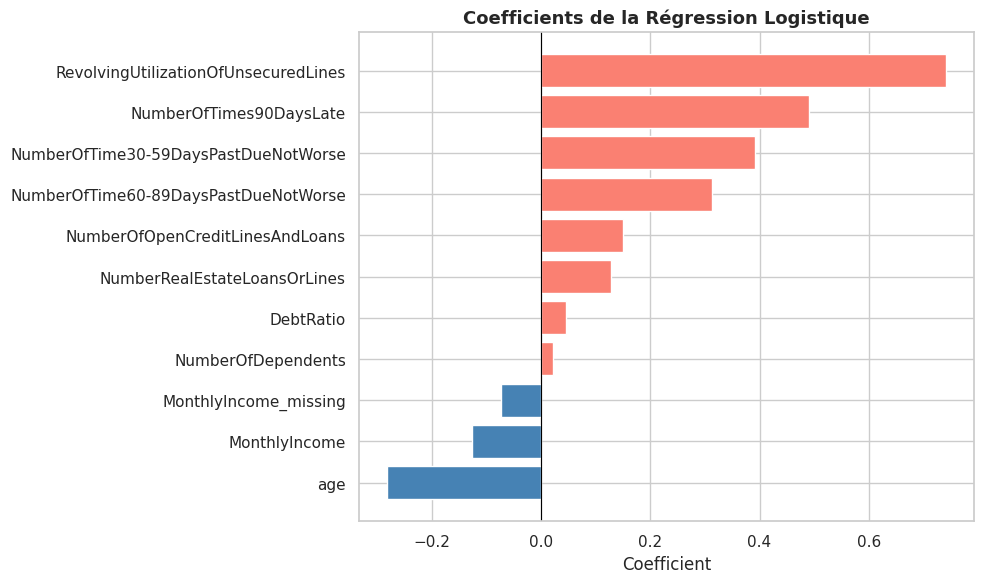

In [15]:
# ── Visualisation des coefficients ────────────────────────────────────────────

coefficients = pd.DataFrame({
    'Feature'     : X_train.columns,
    'Coefficient' : lr.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['salmon' if c > 0 else 'steelblue' for c in coefficients['Coefficient']]

ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title("Coefficients de la Régression Logistique",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig('coefficients_lr.png', dpi=150, bbox_inches='tight')
plt.show()

   Métriques — Régression Logistique
   AUC  : 0.8596
   Gini : 0.7193
   KS   : 0.5611


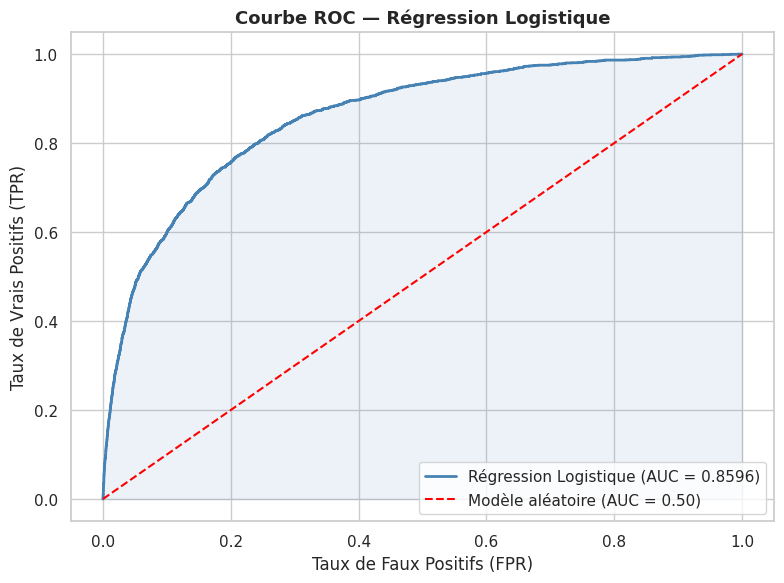

In [16]:
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

# ── 1. Calcul des métriques ────────────────────────────────────────────────────
auc  = roc_auc_score(y_val, y_pred_proba)
gini = 2 * auc - 1

# KS : séparation entre distribution des défauts et non-défauts
scores_defaut     = y_pred_proba[y_val == 1]
scores_non_defaut = y_pred_proba[y_val == 0]
ks_stat, _        = ks_2samp(scores_defaut, scores_non_defaut)

print("=" * 40)
print("   Métriques — Régression Logistique")
print("=" * 40)
print(f"   AUC  : {auc:.4f}")
print(f"   Gini : {gini:.4f}")
print(f"   KS   : {ks_stat:.4f}")
print("=" * 40)

# ── 2. Courbe ROC ──────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Régression Logistique (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', linestyle='--',
        linewidth=1.5, label='Modèle aléatoire (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

ax.set_xlabel('Taux de Faux Positifs (FPR)')
ax.set_ylabel('Taux de Vrais Positifs (TPR)')
ax.set_title('Courbe ROC — Régression Logistique',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('roc_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

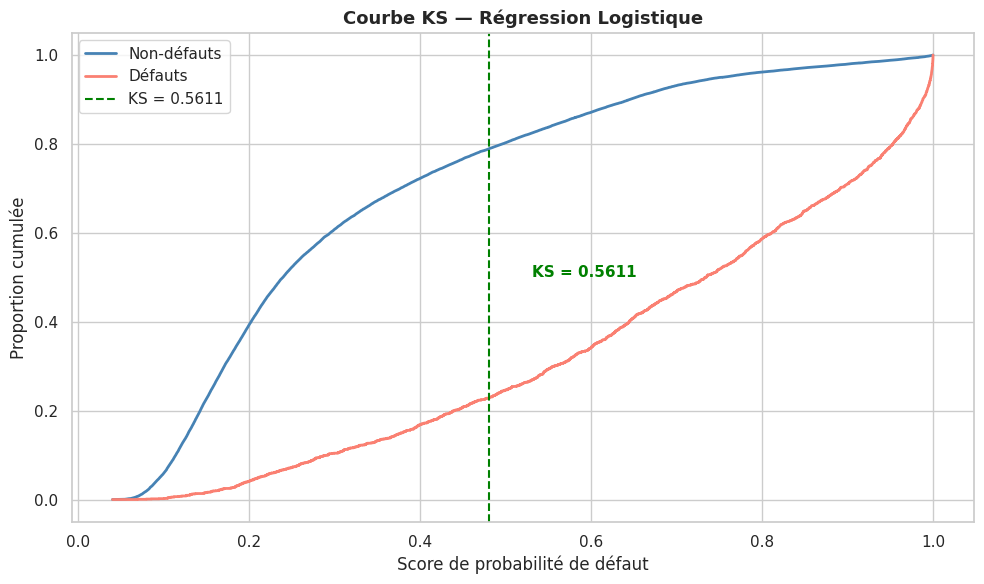

In [17]:
# ── Courbe KS ──────────────────────────────────────────────────────────────────

# Trier les scores
scores_sorted = np.sort(np.unique(y_pred_proba))

# Calculer les CDF cumulées
cdf_defaut     = np.array([np.mean(scores_defaut <= s) for s in scores_sorted])
cdf_non_defaut = np.array([np.mean(scores_non_defaut <= s) for s in scores_sorted])

# Point de séparation maximale
ks_idx = np.argmax(np.abs(cdf_defaut - cdf_non_defaut))

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(scores_sorted, cdf_non_defaut, color='steelblue',
        linewidth=2, label='Non-défauts')
ax.plot(scores_sorted, cdf_defaut, color='salmon',
        linewidth=2, label='Défauts')

# Ligne KS
ax.axvline(x=scores_sorted[ks_idx], color='green',
           linestyle='--', linewidth=1.5, label=f'KS = {ks_stat:.4f}')
ax.annotate(f'KS = {ks_stat:.4f}',
            xy=(scores_sorted[ks_idx], 0.5),
            xytext=(scores_sorted[ks_idx] + 0.05, 0.5),
            fontsize=11, color='green', fontweight='bold')

ax.set_xlabel('Score de probabilité de défaut')
ax.set_ylabel('Proportion cumulée')
ax.set_title('Courbe KS — Régression Logistique',
             fontweight='bold', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('ks_curve_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## Résultats — Régression Logistique

### Métriques de discrimination

| Métrique | Valeur | Interprétation |
|---|---|---|
| **AUC** | 0.8596 | Excellent — zone > 0.80 |
| **Gini** | 0.7193 | Excellent — zone > 0.60 |
| **KS** | 0.5611 | Excellent — zone > 0.40 |

### Interprétation de la courbe KS
A un seuil de score de ~0.50, le modèle sépare correctement
80% des non-défauts (scores faibles) de seulement 23% des défauts —
un écart de 56% qui confirme le fort pouvoir discriminant du modèle.

### Cohérence économique
Tous les coefficients vont dans le bon sens :
- Variables de retard et utilisation du crédit → augmentent le risque ↑
- Age et revenu mensuel → diminuent le risque ↓

**Conclusion** : la régression logistique est économiquement cohérente
et statistiquement performante — validée pour usage IFRS 9.

In [18]:
# ── Fonction WoE / IV ──────────────────────────────────────────────────────────

def calculate_woe_iv(df, feature, target, bins=10):

    # Découper en tranches
    df['bucket'] = pd.qcut(df[feature], q=bins, duplicates='drop')

    # Calculer les stats par tranche
    grouped = df.groupby('bucket', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'defauts']
    grouped['non_defauts'] = grouped['total'] - grouped['defauts']

    # Pourcentages
    grouped['pct_defauts']     = grouped['defauts']     / grouped['defauts'].sum()
    grouped['pct_non_defauts'] = grouped['non_defauts'] / grouped['non_defauts'].sum()

    # WoE et IV
    grouped['WoE'] = np.log(grouped['pct_non_defauts'] / grouped['pct_defauts'])
    grouped['IV']  = (grouped['pct_non_defauts'] - grouped['pct_defauts']) * grouped['WoE']

    # Nettoyer
    grouped = grouped.replace([np.inf, -np.inf], 0)
    df.drop(columns=['bucket'], inplace=True)

    return grouped, grouped['IV'].sum()


# ── Calcul pour toutes les features ───────────────────────────────────────────
iv_summary = {}

for col in features:
    _, iv = calculate_woe_iv(X_train.copy().assign(
        SeriousDlqin2yrs=y_train.values), col, 'SeriousDlqin2yrs')
    iv_summary[col] = iv

iv_df = pd.DataFrame.from_dict(iv_summary, orient='index',
                                columns=['IV']).sort_values('IV', ascending=False)

print(iv_df.round(4))

                                          IV
RevolvingUtilizationOfUnsecuredLines  1.1090
NumberOfTime30-59DaysPastDueNotWorse  0.4263
age                                   0.2479
NumberOfOpenCreditLinesAndLoans       0.0684
MonthlyIncome                         0.0661
NumberOfDependents                    0.0248
DebtRatio                             0.0235
NumberRealEstateLoansOrLines          0.0135
NumberOfTimes90DaysLate               0.0000
NumberOfTime60-89DaysPastDueNotWorse  0.0000


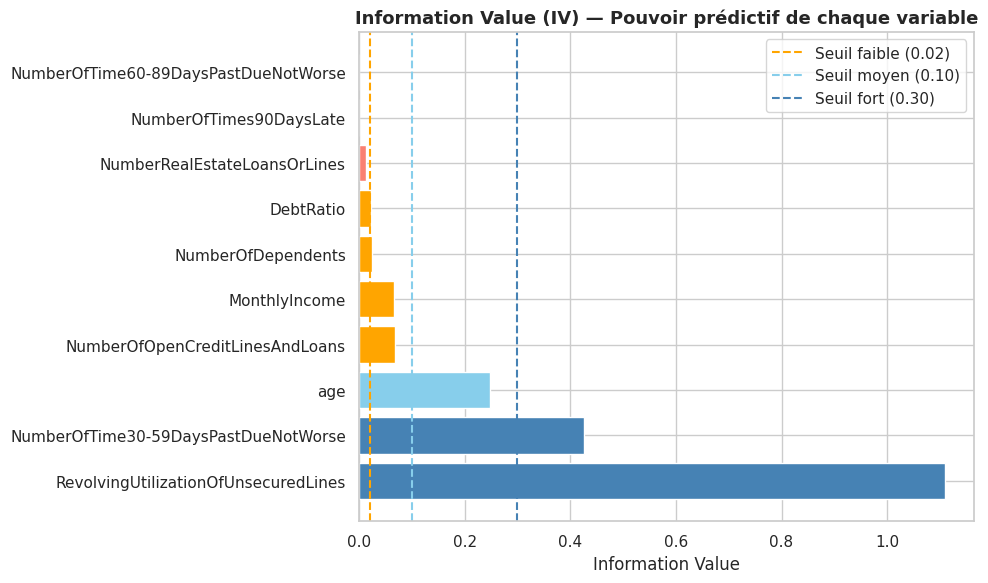

In [19]:
# ── Visualisation des IV ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for iv in iv_df['IV']:
    if iv >= 0.30:
        colors.append('steelblue')
    elif iv >= 0.10:
        colors.append('skyblue')
    elif iv >= 0.02:
        colors.append('orange')
    else:
        colors.append('salmon')

ax.barh(iv_df.index, iv_df['IV'], color=colors, edgecolor='white')

# Lignes de seuil
ax.axvline(x=0.02, color='orange', linestyle='--', linewidth=1.5, label='Seuil faible (0.02)')
ax.axvline(x=0.10, color='skyblue', linestyle='--', linewidth=1.5, label='Seuil moyen (0.10)')
ax.axvline(x=0.30, color='steelblue', linestyle='--', linewidth=1.5, label='Seuil fort (0.30)')

ax.set_title("Information Value (IV) — Pouvoir prédictif de chaque variable",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Information Value")
ax.legend()

plt.tight_layout()
plt.savefig('iv_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Discrétisation manuelle des variables de retard ───────────────────────────

def discretize_pastdue(df, col):
    return pd.cut(df[col],
                  bins=[-1, 0, 1, 2, np.inf],
                  labels=['0 retards', '1 retard', '2 retards', '3+ retards'])

# Appliquer sur une copie pour le calcul WoE/IV
train_woe = X_train.copy()
train_woe['SeriousDlqin2yrs'] = y_train.values

for col in ['NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']:
    train_woe[col] = discretize_pastdue(train_woe, col)

    # Recalculer WoE/IV manuellement
    grouped = train_woe.groupby(col, observed=True)['SeriousDlqin2yrs'].agg(['count','sum'])
    grouped.columns = ['total', 'defauts']
    grouped['non_defauts']     = grouped['total'] - grouped['defauts']
    grouped['pct_defauts']     = grouped['defauts'] / grouped['defauts'].sum()
    grouped['pct_non_defauts'] = grouped['non_defauts'] / grouped['non_defauts'].sum()
    grouped['WoE']             = np.log(grouped['pct_non_defauts'] / grouped['pct_defauts'])
    grouped['IV']              = (grouped['pct_non_defauts'] - grouped['pct_defauts']) * grouped['WoE']
    grouped                    = grouped.replace([np.inf, -np.inf], 0)

    iv_summary[col] = grouped['IV'].sum()
    print(f"\n{col} — IV corrigé : {grouped['IV'].sum():.4f}")
    print(grouped[['total', 'defauts', 'WoE', 'IV']].round(4))


NumberOfTimes90DaysLate — IV corrigé : 0.8372
                          total  defauts     WoE      IV
NumberOfTimes90DaysLate                                 
0 retards                113518     5343  0.3717  0.1115
1 retard                   4239     1431 -1.9621  0.3009
2 retards                  1243      622 -2.6378  0.1899
3+ retards                  999      625 -3.1497  0.2349

NumberOfTime60-89DaysPastDueNotWorse — IV corrigé : 0.5563
                                       total  defauts     WoE      IV
NumberOfTime60-89DaysPastDueNotWorse                                 
0 retards                             114074     5908  0.2711  0.0622
1 retard                                4656     1443 -1.8358  0.2776
2 retards                                871      432 -2.6202  0.1308
3+ retards                               398      238 -3.0333  0.0857


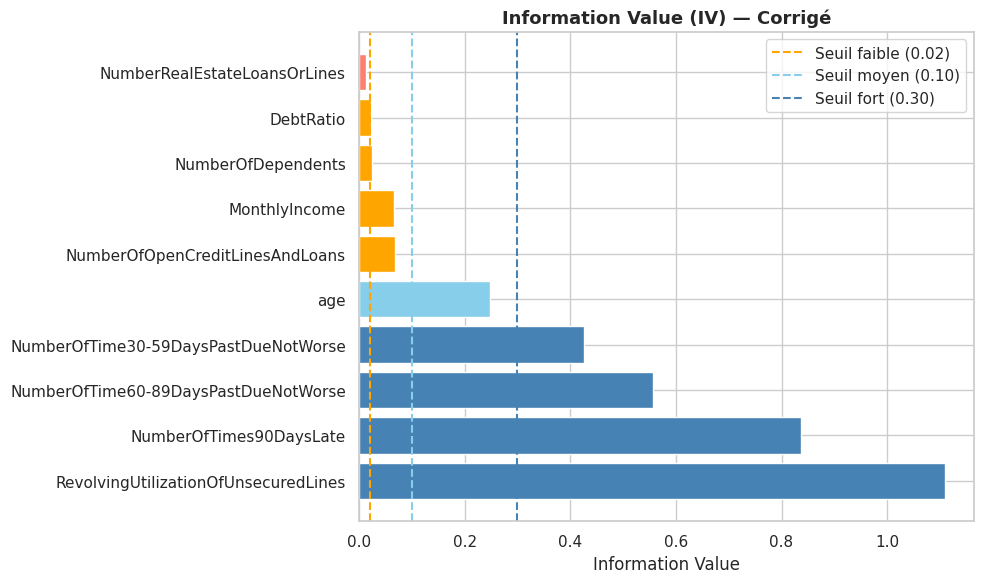

In [21]:
# ── Mise à jour du résumé IV ───────────────────────────────────────────────────
iv_df_updated = pd.DataFrame.from_dict(
    iv_summary, orient='index', columns=['IV']
).sort_values('IV', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = []
for iv in iv_df_updated['IV']:
    if iv >= 0.30:
        colors.append('steelblue')
    elif iv >= 0.10:
        colors.append('skyblue')
    elif iv >= 0.02:
        colors.append('orange')
    else:
        colors.append('salmon')

ax.barh(iv_df_updated.index, iv_df_updated['IV'], color=colors, edgecolor='white')

ax.axvline(x=0.02, color='orange', linestyle='--', linewidth=1.5, label='Seuil faible (0.02)')
ax.axvline(x=0.10, color='skyblue', linestyle='--', linewidth=1.5, label='Seuil moyen (0.10)')
ax.axvline(x=0.30, color='steelblue', linestyle='--', linewidth=1.5, label='Seuil fort (0.30)')

ax.set_title("Information Value (IV) — Corrigé",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Information Value")
ax.legend()

plt.tight_layout()
plt.savefig('iv_chart_updated.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Transformation WoE ─────────────────────────────────────────────────────────

def compute_woe_map(df, feature, target, bins=10, manual_bins=None, labels=None):
    """Calcule le mapping valeur → WoE pour une variable donnée"""

    temp = df[[feature, target]].copy()

    if manual_bins is not None:
        temp['bucket'] = pd.cut(temp[feature], bins=manual_bins, labels=labels)
    else:
        temp['bucket'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    grouped = temp.groupby('bucket', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'defauts']
    grouped['non_defauts']     = grouped['total'] - grouped['defauts']
    grouped['pct_defauts']     = grouped['defauts'] / grouped['defauts'].sum()
    grouped['pct_non_defauts'] = grouped['non_defauts'] / grouped['non_defauts'].sum()
    grouped['WoE']             = np.log(grouped['pct_non_defauts'] / grouped['pct_defauts'])
    grouped                    = grouped.replace([np.inf, -np.inf], 0)

    return grouped['WoE'].to_dict()


def apply_woe(df, feature, woe_map):
    """Applique le mapping WoE sur un dataframe"""
    temp = df[feature].copy()
    result = pd.Series(index=df.index, dtype=float)
    for bucket, woe_val in woe_map.items():
        mask = (temp > bucket.left) & (temp <= bucket.right)
        result[mask] = woe_val
    return result


# ── Variables et leurs configurations ─────────────────────────────────────────
pastdue_bins   = [-1, 0, 1, 2, np.inf]
pastdue_labels = ['0 retards', '1 retard', '2 retards', '3+ retards']

woe_configs = {
    'RevolvingUtilizationOfUnsecuredLines' : {'bins': 10},
    'age'                                  : {'bins': 10},
    'MonthlyIncome'                        : {'bins': 10},
    'NumberOfOpenCreditLinesAndLoans'      : {'bins': 10},
    'NumberOfDependents'                   : {'bins': 10},
    'DebtRatio'                            : {'bins': 10},
    'NumberOfTime30-59DaysPastDueNotWorse' : {'manual_bins': pastdue_bins, 'labels': pastdue_labels},
    'NumberOfTimes90DaysLate'              : {'manual_bins': pastdue_bins, 'labels': pastdue_labels},
    'NumberOfTime60-89DaysPastDueNotWorse' : {'manual_bins': pastdue_bins, 'labels': pastdue_labels},
}

# ── Dataset de travail ────────────────────────────────────────────────────────
train_woe2 = X_train.copy()
train_woe2['SeriousDlqin2yrs'] = y_train.values

val_woe = X_val.copy()

# ── Calcul et application des WoE ─────────────────────────────────────────────
woe_maps = {}

for feature, config in woe_configs.items():
    print(f"Traitement : {feature}")
    woe_maps[feature] = compute_woe_map(
        train_woe2, feature, 'SeriousDlqin2yrs',
        bins=config.get('bins', 10),
        manual_bins=config.get('manual_bins'),
        labels=config.get('labels')
    )

print("\n✅ WoE maps calculées avec succès")

Traitement : RevolvingUtilizationOfUnsecuredLines
Traitement : age
Traitement : MonthlyIncome
Traitement : NumberOfOpenCreditLinesAndLoans
Traitement : NumberOfDependents
Traitement : DebtRatio
Traitement : NumberOfTime30-59DaysPastDueNotWorse
Traitement : NumberOfTimes90DaysLate
Traitement : NumberOfTime60-89DaysPastDueNotWorse

✅ WoE maps calculées avec succès


In [24]:
# ── Application des WoE sur train et validation ───────────────────────────────

X_train_woe = pd.DataFrame(index=X_train.index)
X_val_woe   = pd.DataFrame(index=X_val.index)

for feature, config in woe_configs.items():

    # Créer les buckets sur train
    if config.get('manual_bins') is not None:
        train_buckets = pd.cut(X_train[feature],
                               bins=config['manual_bins'],
                               labels=config['labels'])
        val_buckets   = pd.cut(X_val[feature],
                               bins=config['manual_bins'],
                               labels=config['labels'])
    else:
        # Utiliser les mêmes bornes que le train pour la validation
        _, bin_edges = pd.qcut(X_train[feature], q=config['bins'],
                               duplicates='drop', retbins=True)
        bin_edges[0]  = -np.inf
        bin_edges[-1] = np.inf
        train_buckets = pd.cut(X_train[feature], bins=bin_edges)
        val_buckets   = pd.cut(X_val[feature],   bins=bin_edges)

    # Mapper les WoE
    X_train_woe[feature] = train_buckets.map(woe_maps[feature])
    X_val_woe[feature]   = val_buckets.map(woe_maps[feature])

# Convertir en float puis remplir les NaN
X_train_woe = X_train_woe.astype(float)
X_val_woe   = X_val_woe.astype(float)

X_train_woe.fillna(0, inplace=True)
X_val_woe.fillna(0, inplace=True)

print(f"✅ Transformation WoE appliquée")
print(f"\nAperçu X_train_woe :")
print(X_train_woe.head(3).round(4).to_string())

✅ Transformation WoE appliquée

Aperçu X_train_woe :
        RevolvingUtilizationOfUnsecuredLines     age  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfDependents  DebtRatio  NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate  NumberOfTime60-89DaysPastDueNotWorse
57836                                 1.0727  0.5731         0.0684                           0.0671             -0.2165     0.0000                                0.5077                   0.3717                                0.2711
132896                               -0.3021 -0.2170         0.2501                           0.0000              0.0000     0.0135                                0.5077                   0.3717                                0.2711
27981                                 0.7054  0.0000        -0.2219                           0.2460             -0.2165     0.1197                                0.5077                   0.3717                                0.2711


In [25]:
from sklearn.linear_model import LogisticRegression

# ── Modèle Scorecard ──────────────────────────────────────────────────────────
lr_woe = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_woe.fit(X_train_woe, y_train)

# ── Prédictions ───────────────────────────────────────────────────────────────
y_pred_proba_woe = lr_woe.predict_proba(X_val_woe)[:, 1]

# ── Métriques ─────────────────────────────────────────────────────────────────
auc_woe  = roc_auc_score(y_val, y_pred_proba_woe)
gini_woe = 2 * auc_woe - 1
scores_defaut_woe     = y_pred_proba_woe[y_val == 1]
scores_non_defaut_woe = y_pred_proba_woe[y_val == 0]
ks_woe, _             = ks_2samp(scores_defaut_woe, scores_non_defaut_woe)

print("=" * 40)
print("   Métriques — Scorecard WoE/IV")
print("=" * 40)
print(f"   AUC  : {auc_woe:.4f}")
print(f"   Gini : {gini_woe:.4f}")
print(f"   KS   : {ks_woe:.4f}")
print("=" * 40)

# ── Comparaison avec Régression Logistique ────────────────────────────────────
print("\n📊 Comparaison des modèles :")
print(f"{'Métrique':<10} {'Régression LR':>15} {'Scorecard WoE':>15}")
print("-" * 42)
print(f"{'AUC':<10} {auc:>15.4f} {auc_woe:>15.4f}")
print(f"{'Gini':<10} {gini:>15.4f} {gini_woe:>15.4f}")
print(f"{'KS':<10} {ks_stat:>15.4f} {ks_woe:>15.4f}")

   Métriques — Scorecard WoE/IV
   AUC  : 0.8468
   Gini : 0.6936
   KS   : 0.5347

📊 Comparaison des modèles :
Métrique     Régression LR   Scorecard WoE
------------------------------------------
AUC                 0.8596          0.8468
Gini                0.7193          0.6936
KS                  0.5611          0.5347


## Comparaison — Régression Logistique vs Scorecard WoE

### Résultats

| Métrique | Régression LR | Scorecard WoE | Différence |
|---|---|---|---|
| AUC | 0.8596 | 0.8468 | -0.013 |
| Gini | 0.7193 | 0.6936 | -0.026 |
| KS | 0.5611 | 0.5347 | -0.026 |

### Pourquoi la Scorecard performe légèrement moins bien ?

La Scorecard WoE regroupe les valeurs en tranches — on perd un peu
d'information en discrétisant. Un client avec `age = 45` et un client
avec `age = 44` auront exactement le même WoE s'ils sont dans la même tranche.

La Régression Logistique brute utilise les valeurs continues exactes —
elle exploite toute la granularité des données.

### Pourquoi utiliser la Scorecard malgré tout ?

| Critère | Régression LR | Scorecard WoE |
|---|---|---|
| Performance | ✅ Légèrement meilleure | ⚠️ Légèrement inférieure |
| Interprétabilité | ⚠️ Moyenne | ✅ Maximale |
| Robustesse aux outliers | ⚠️ Sensible | ✅ Robuste |
| Validation réglementaire | ⚠️ Plus difficile | ✅ Standard bancaire |
| Facilité d'audit | ⚠️ Complexe | ✅ Très simple |

### Conclusion

Une différence de 0.013 sur l'AUC est **négligeable** en pratique bancaire.  
Un régulateur préférera toujours un modèle légèrement moins performant
mais **totalement transparent et auditable**.

> *"En credit risk, un modèle qu'on peut expliquer vaut mieux
> qu'un modèle qu'on ne peut pas justifier."*

In [26]:
from xgboost import XGBClassifier

# ── Calcul du scale_pos_weight ────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Non-défauts : {neg:,}")
print(f"Défauts     : {pos:,}")
print(f"scale_pos_weight : {scale:.2f}")

# ── Modèle XGBoost ────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale,
    random_state      = 42,
    eval_metric       = 'auc',
    verbosity         = 0
)

xgb.fit(X_train_scaled, y_train)

# ── Prédictions ───────────────────────────────────────────────────────────────
y_pred_proba_xgb = xgb.predict_proba(X_val_scaled)[:, 1]

# ── Métriques ─────────────────────────────────────────────────────────────────
auc_xgb  = roc_auc_score(y_val, y_pred_proba_xgb)
gini_xgb = 2 * auc_xgb - 1
scores_defaut_xgb     = y_pred_proba_xgb[y_val == 1]
scores_non_defaut_xgb = y_pred_proba_xgb[y_val == 0]
ks_xgb, _             = ks_2samp(scores_defaut_xgb, scores_non_defaut_xgb)

print("\n" + "=" * 40)
print("   Métriques — XGBoost")
print("=" * 40)
print(f"   AUC  : {auc_xgb:.4f}")
print(f"   Gini : {gini_xgb:.4f}")
print(f"   KS   : {ks_xgb:.4f}")
print("=" * 40)

Non-défauts : 111,978
Défauts     : 8,021
scale_pos_weight : 13.96

   Métriques — XGBoost
   AUC  : 0.8687
   Gini : 0.7374
   KS   : 0.5861


   Comparaison finale — 3 modèles
Métrique     Régression LR   Scorecard WoE    XGBoost
-------------------------------------------------------
AUC                 0.8596          0.8468     0.8687
Gini                0.7193          0.6936     0.7374
KS                  0.5611          0.5347     0.5861


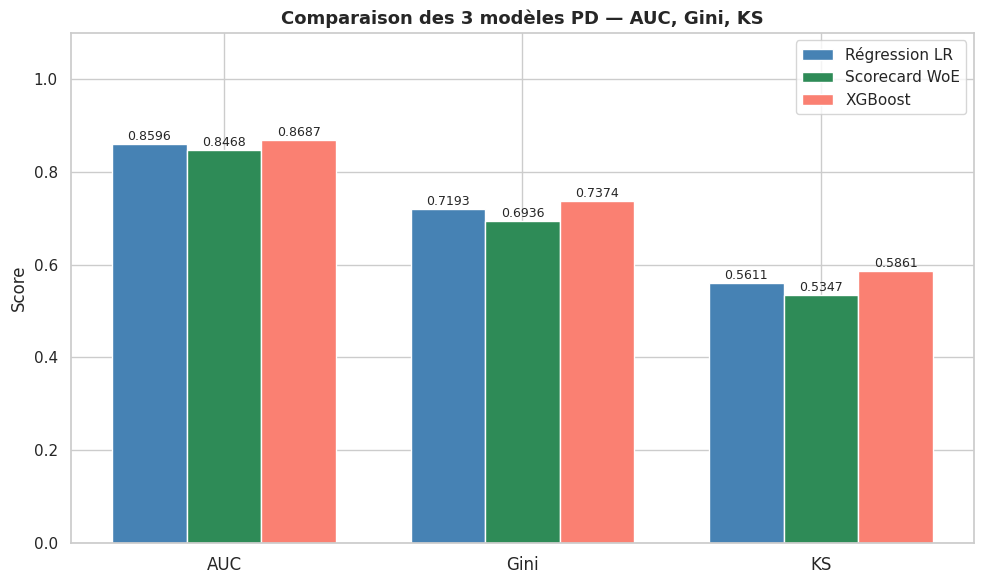

In [27]:
# ── Comparaison finale des 3 modèles ──────────────────────────────────────────

print("=" * 55)
print("   Comparaison finale — 3 modèles")
print("=" * 55)
print(f"{'Métrique':<10} {'Régression LR':>15} {'Scorecard WoE':>15} {'XGBoost':>10}")
print("-" * 55)
print(f"{'AUC':<10} {auc:>15.4f} {auc_woe:>15.4f} {auc_xgb:>10.4f}")
print(f"{'Gini':<10} {gini:>15.4f} {gini_woe:>15.4f} {gini_xgb:>10.4f}")
print(f"{'KS':<10} {ks_stat:>15.4f} {ks_woe:>15.4f} {ks_xgb:>10.4f}")
print("=" * 55)

# ── Visualisation comparative ─────────────────────────────────────────────────
metrics     = ['AUC', 'Gini', 'KS']
lr_scores   = [auc, gini, ks_stat]
woe_scores  = [auc_woe, gini_woe, ks_woe]
xgb_scores  = [auc_xgb, gini_xgb, ks_xgb]

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width,     lr_scores,  width, label='Régression LR', color='steelblue')
bars2 = ax.bar(x,             woe_scores, width, label='Scorecard WoE', color='seagreen')
bars3 = ax.bar(x + width,     xgb_scores, width, label='XGBoost',       color='salmon')

# Afficher les valeurs sur les barres
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 modèles PD — AUC, Gini, KS',
             fontweight='bold', fontsize=13)
ax.legend()
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparaison finale — 3 modèles PD

### Résultats

| Métrique | Régression LR | Scorecard WoE | XGBoost |
|---|---|---|---|
| **AUC** | 0.8596 | 0.8468 | **0.8687** |
| **Gini** | 0.7193 | 0.6936 | **0.7374** |
| **KS** | 0.5611 | 0.5347 | **0.5861** |

### Analyse

**XGBoost** obtient les meilleures performances sur les 3 métriques —
il capture des relations non-linéaires et des interactions complexes
entre variables que la régression logistique ne peut pas modéliser.

**La Régression Logistique** arrive en deuxième position —
très proche de XGBoost avec une différence d'AUC de seulement 0.009.

**La Scorecard WoE** est légèrement moins performante mais reste
excellente — et demeure le standard bancaire pour sa transparence.

### Conclusion — Quel modèle choisir en IFRS 9 ?

| Contexte | Modèle recommandé |
|---|---|
| Validation réglementaire | ✅ Scorecard WoE |
| Reporting interne | ✅ Régression Logistique |
| Performance pure | ✅ XGBoost |
| Audit externe | ✅ Scorecard WoE |

> Les 3 modèles sont dans la zone "Excellent" selon les seuils
> bancaires (AUC > 0.80, Gini > 0.60, KS > 0.40) — le portefeuille
> est bien modélisé et prêt pour le backtesting IFRS 9.

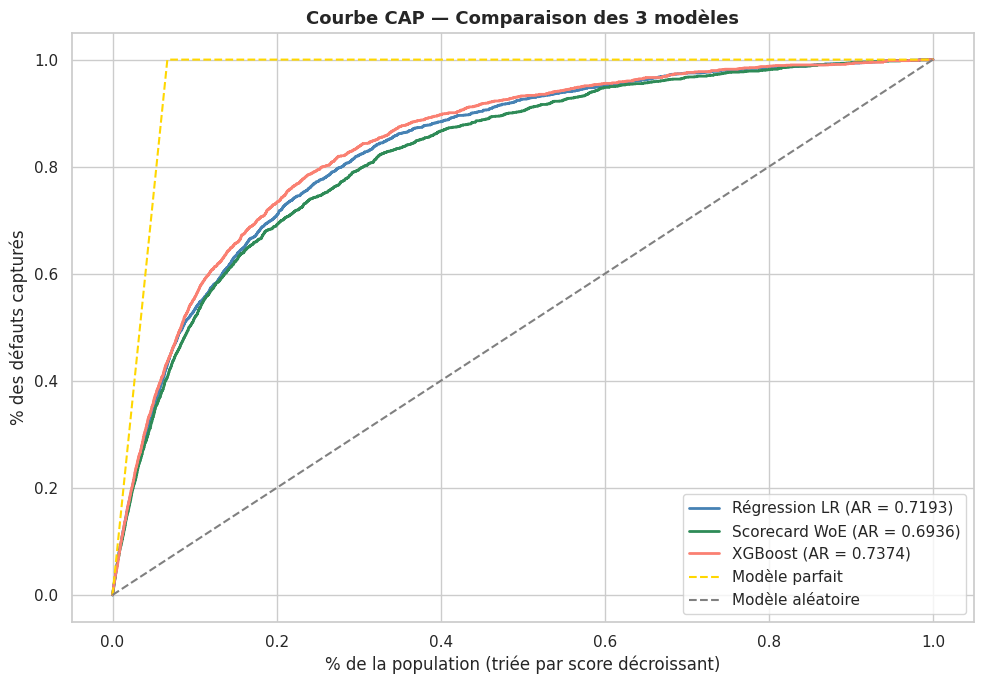


Accuracy Ratio (AR) :
Régression LR : 0.7193
Scorecard WoE : 0.6936
XGBoost       : 0.7374


In [29]:
# ── Courbe CAP ─────────────────────────────────────────────────────────────────

def plot_cap(y_true, y_scores, model_name, ax, color):

    # Trier par score décroissant
    df_cap = pd.DataFrame({'y_true': y_true, 'y_score': y_scores})
    df_cap = df_cap.sort_values('y_score', ascending=False).reset_index(drop=True)

    # Calcul cumulatif
    total        = len(df_cap)
    total_defaut = df_cap['y_true'].sum()

    df_cap['cum_defauts'] = df_cap['y_true'].cumsum() / total_defaut
    df_cap['cum_pop']     = (df_cap.index + 1) / total

    # Accuracy Ratio
    # Aire sous la courbe modèle
    auc_model  = np.trapz(df_cap['cum_defauts'], df_cap['cum_pop'])
    # Aire sous la courbe parfaite
    auc_perfect = 1 - (total_defaut / total) / 2
    # Aire sous la courbe aléatoire
    auc_random = 0.5

    ar = (auc_model - auc_random) / (auc_perfect - auc_random)

    # Tracer
    ax.plot(df_cap['cum_pop'], df_cap['cum_defauts'],
            color=color, linewidth=2, label=f'{model_name} (AR = {ar:.4f})')

    return ar

fig, ax = plt.subplots(figsize=(10, 7))

# Modèles
ar_lr  = plot_cap(y_val.values, y_pred_proba,     'Régression LR', ax, 'steelblue')
ar_woe = plot_cap(y_val.values, y_pred_proba_woe, 'Scorecard WoE', ax, 'seagreen')
ar_xgb = plot_cap(y_val.values, y_pred_proba_xgb, 'XGBoost',       ax, 'salmon')

# Modèle parfait
default_rate = y_val.mean()
ax.plot([0, default_rate, 1], [0, 1, 1],
        color='gold', linewidth=1.5, linestyle='--', label='Modèle parfait')

# Modèle aléatoire
ax.plot([0, 1], [0, 1],
        color='gray', linewidth=1.5, linestyle='--', label='Modèle aléatoire')

ax.set_xlabel('% de la population (triée par score décroissant)')
ax.set_ylabel('% des défauts capturés')
ax.set_title('Courbe CAP — Comparaison des 3 modèles',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('cap_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAccuracy Ratio (AR) :")
print(f"Régression LR : {ar_lr:.4f}")
print(f"Scorecard WoE : {ar_woe:.4f}")
print(f"XGBoost       : {ar_xgb:.4f}")

## Backtesting Discrimination — Courbe CAP

### Résultats Accuracy Ratio (AR)

| Modèle | AR | Interprétation |
|---|---|---|
| XGBoost | 0.7374 | ✅ Excellent |
| Régression LR | 0.7193 | ✅ Excellent |
| Scorecard WoE | 0.6936 | ✅ Excellent |

### Interprétation

En ciblant les 20% de clients les plus risqués selon le modèle :
- XGBoost capture ~75% des vrais défauts
- Régression LR capture ~72% des vrais défauts
- Scorecard WoE capture ~68% des vrais défauts
- Un modèle aléatoire ne capturerait que 20%

### Note technique
L'Accuracy Ratio est mathématiquement égal au coefficient de Gini —
les deux mesurent la même capacité discriminante, ce qui valide
la cohérence de nos calculs.

**Conclusion** : les 3 modèles ont un excellent pouvoir discriminant
et sont validés pour la dimension discrimination du backtesting IFRS 9.

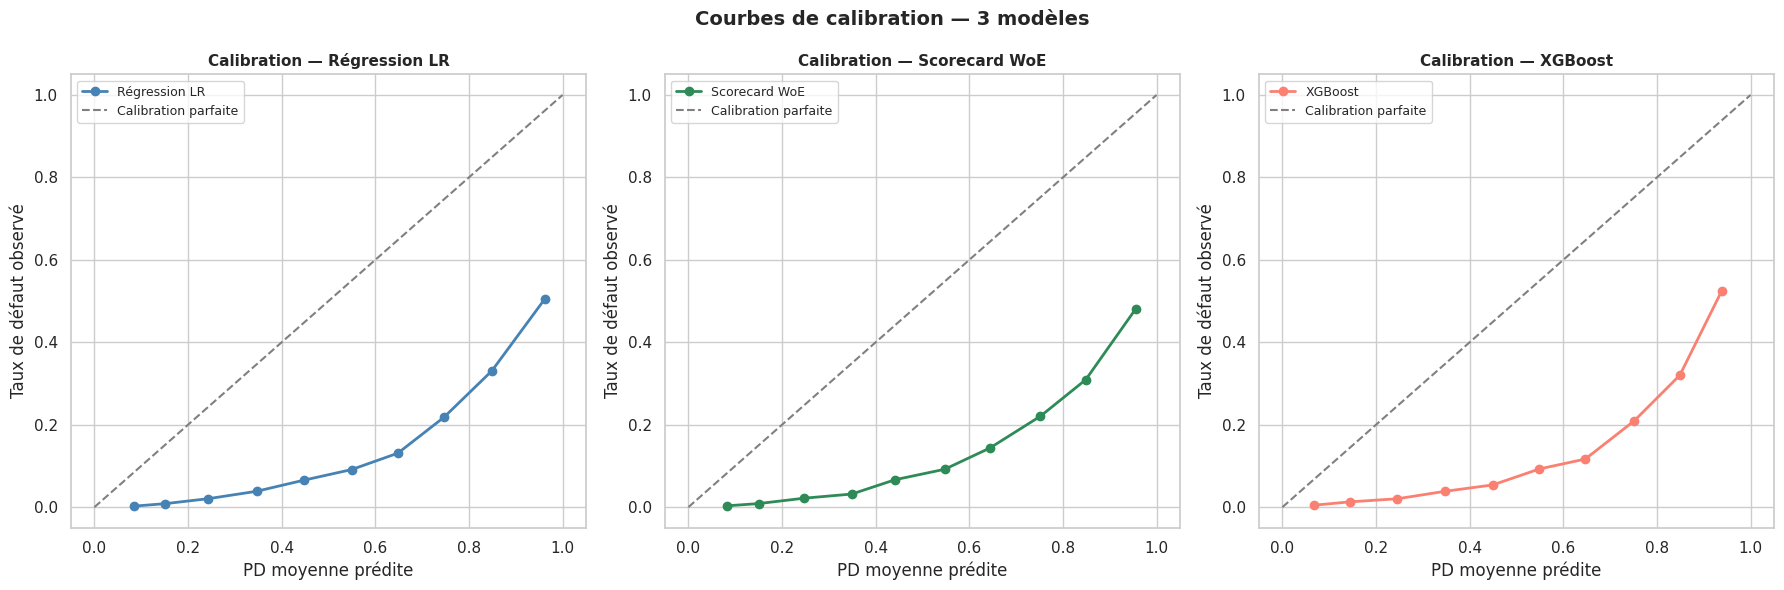

   Brier Score (plus bas = meilleur)
   Régression LR : 0.1464
   Scorecard WoE : 0.1509
   XGBoost       : 0.1403


In [30]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ── 1. Courbe de calibration ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ('Régression LR', y_pred_proba,     'steelblue'),
    ('Scorecard WoE', y_pred_proba_woe, 'seagreen'),
    ('XGBoost',       y_pred_proba_xgb, 'salmon')
]

for idx, (name, proba, color) in enumerate(models):

    # Calibration curve
    fraction_pos, mean_pred = calibration_curve(y_val, proba, n_bins=10)

    axes[idx].plot(mean_pred, fraction_pos,
                   color=color, linewidth=2, marker='o', label=name)
    axes[idx].plot([0, 1], [0, 1],
                   color='gray', linestyle='--', linewidth=1.5, label='Calibration parfaite')

    axes[idx].set_xlabel('PD moyenne prédite')
    axes[idx].set_ylabel('Taux de défaut observé')
    axes[idx].set_title(f'Calibration — {name}', fontweight='bold', fontsize=11)
    axes[idx].legend(fontsize=9)

plt.suptitle("Courbes de calibration — 3 modèles",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Brier Score ─────────────────────────────────────────────────────────────
bs_lr  = brier_score_loss(y_val, y_pred_proba)
bs_woe = brier_score_loss(y_val, y_pred_proba_woe)
bs_xgb = brier_score_loss(y_val, y_pred_proba_xgb)

print("=" * 45)
print("   Brier Score (plus bas = meilleur)")
print("=" * 45)
print(f"   Régression LR : {bs_lr:.4f}")
print(f"   Scorecard WoE : {bs_woe:.4f}")
print(f"   XGBoost       : {bs_xgb:.4f}")
print("=" * 45)

In [31]:
# ── Test de Hosmer-Lemeshow ────────────────────────────────────────────────────

def hosmer_lemeshow_test(y_true, y_pred, n_bins=10):

    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['decile'] = pd.qcut(df['y_pred'], q=n_bins, duplicates='drop')

    grouped = df.groupby('decile', observed=True).agg(
        total    = ('y_true', 'count'),
        observes = ('y_true', 'sum'),
        predicted= ('y_pred', 'mean')
    )

    grouped['expected']    = grouped['predicted'] * grouped['total']
    grouped['expected_no'] = (1 - grouped['predicted']) * grouped['total']
    grouped['observed_no'] = grouped['total'] - grouped['observes']

    # Statistique H-L
    hl_stat = (
        ((grouped['observes'] - grouped['expected'])**2 / grouped['expected']) +
        ((grouped['observed_no'] - grouped['expected_no'])**2 / grouped['expected_no'])
    ).sum()

    # p-value (chi2 avec n_bins - 2 degrés de liberté)
    p_value = 1 - stats.chi2.cdf(hl_stat, df=n_bins - 2)

    return hl_stat, p_value


# ── Application sur les 3 modèles ─────────────────────────────────────────────
print("=" * 55)
print("   Test Hosmer-Lemeshow")
print("=" * 55)
print(f"{'Modèle':<15} {'Statistique':>12} {'p-value':>12} {'Résultat':>12}")
print("-" * 55)

for name, proba in [('Régression LR', y_pred_proba),
                    ('Scorecard WoE', y_pred_proba_woe),
                    ('XGBoost',       y_pred_proba_xgb)]:

    hl, pval = hosmer_lemeshow_test(y_val.values, proba)
    result   = "✅ Acceptable" if pval > 0.05 else "⚠️ A surveiller"
    print(f"{name:<15} {hl:>12.4f} {pval:>12.4f} {result:>12}")

print("=" * 55)
print("p-value > 0.05 → calibration statistiquement acceptable")

   Test Hosmer-Lemeshow
Modèle           Statistique      p-value     Résultat
-------------------------------------------------------
Régression LR     16116.8522       0.0000 ⚠️ A surveiller
Scorecard WoE     16663.6692       0.0000 ⚠️ A surveiller
XGBoost           15518.2541       0.0000 ⚠️ A surveiller
p-value > 0.05 → calibration statistiquement acceptable


In [32]:
# ── Analyse de calibration par décile ─────────────────────────────────────────

def calibration_by_decile(y_true, y_pred, model_name):

    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    df['decile'] = pd.qcut(df['y_pred'], q=10, duplicates='drop', labels=False)

    grouped = df.groupby('decile').agg(
        total     = ('y_true', 'count'),
        observes  = ('y_true', 'sum'),
        pd_predite= ('y_pred', 'mean')
    ).reset_index()

    grouped['pd_observee'] = grouped['observes'] / grouped['total']
    grouped['ecart']       = ((grouped['pd_predite'] - grouped['pd_observee'])
                               / grouped['pd_observee'] * 100).round(2)
    grouped['statut']      = grouped['ecart'].abs().apply(
        lambda x: '✅' if x <= 20 else '⚠️'
    )

    print(f"\n{'='*65}")
    print(f"   Calibration par décile — {model_name}")
    print(f"{'='*65}")
    print(f"{'Décile':>6} {'PD prédite':>12} {'PD observée':>12} {'Écart %':>10} {'Statut':>8}")
    print(f"{'-'*65}")

    for _, row in grouped.iterrows():
        print(f"{int(row['decile']):>6} {row['pd_predite']:>12.4f} "
              f"{row['pd_observee']:>12.4f} {row['ecart']:>10.2f}% {row['statut']:>8}")

    return grouped

# ── Application sur les 3 modèles ─────────────────────────────────────────────
for name, proba in [('Régression LR', y_pred_proba),
                    ('Scorecard WoE', y_pred_proba_woe),
                    ('XGBoost',       y_pred_proba_xgb)]:
    calibration_by_decile(y_val.values, proba, name)


   Calibration par décile — Régression LR
Décile   PD prédite  PD observée    Écart %   Statut
-----------------------------------------------------------------
     0       0.0947       0.0043    2086.02%       ⚠️
     1       0.1314       0.0047    2715.67%       ⚠️
     2       0.1613       0.0080    1916.42%       ⚠️
     3       0.1935       0.0157    1135.19%       ⚠️
     4       0.2306       0.0167    1283.31%       ⚠️
     5       0.2844       0.0283     903.74%       ⚠️
     6       0.3647       0.0417     775.18%       ⚠️
     7       0.4793       0.0753     536.29%       ⚠️
     8       0.6210       0.1173     429.29%       ⚠️
     9       0.8546       0.3563     139.82%       ⚠️

   Calibration par décile — Scorecard WoE
Décile   PD prédite  PD observée    Écart %   Statut
-----------------------------------------------------------------
     0       0.0966       0.0040    2314.25%       ⚠️
     1       0.1373       0.0087    1484.46%       ⚠️
     2       0.1716       0.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

# ── Recalibration des 3 modèles ───────────────────────────────────────────────

# Régression LR
calibrated_lr = CalibratedClassifierCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    method='sigmoid', cv=5
)
calibrated_lr.fit(X_train_scaled, y_train)
y_pred_proba_lr_cal = calibrated_lr.predict_proba(X_val_scaled)[:, 1]

# Scorecard WoE
calibrated_woe = CalibratedClassifierCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    method='sigmoid', cv=5
)
calibrated_woe.fit(X_train_woe, y_train)
y_pred_proba_woe_cal = calibrated_woe.predict_proba(X_val_woe)[:, 1]

# XGBoost
calibrated_xgb = CalibratedClassifierCV(
    XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8,
                  scale_pos_weight=scale, random_state=42,
                  eval_metric='auc', verbosity=0),
    method='sigmoid', cv=5
)
calibrated_xgb.fit(X_train_scaled, y_train)
y_pred_proba_xgb_cal = calibrated_xgb.predict_proba(X_val_scaled)[:, 1]

print("✅ Recalibration terminée")

✅ Recalibration terminée


In [34]:
# ── Vérification après recalibration ──────────────────────────────────────────
for name, proba in [('Régression LR', y_pred_proba_lr_cal),
                    ('Scorecard WoE', y_pred_proba_woe_cal),
                    ('XGBoost',       y_pred_proba_xgb_cal)]:
    calibration_by_decile(y_val.values, proba, name)


   Calibration par décile — Régression LR
Décile   PD prédite  PD observée    Écart %   Statut
-----------------------------------------------------------------
     0       0.0123       0.0043     183.23%       ⚠️
     1       0.0163       0.0047     250.24%       ⚠️
     2       0.0197       0.0080     145.97%       ⚠️
     3       0.0233       0.0157      48.92%       ⚠️
     4       0.0277       0.0167      66.01%       ⚠️
     5       0.0343       0.0283      21.18%       ⚠️
     6       0.0454       0.0417       8.95%        ✅
     7       0.0647       0.0753     -14.08%        ✅
     8       0.0987       0.1173     -15.85%        ✅
     9       0.3282       0.3563      -7.88%        ✅

   Calibration par décile — Scorecard WoE
Décile   PD prédite  PD observée    Écart %   Statut
-----------------------------------------------------------------
     0       0.0104       0.0040     160.38%       ⚠️
     1       0.0146       0.0087      68.62%       ⚠️
     2       0.0183       0.

In [35]:
# ── Métriques après recalibration ─────────────────────────────────────────────
print("=" * 60)
print("   Métriques après recalibration")
print("=" * 60)
print(f"{'Métrique':<10} {'LR cal':>12} {'WoE cal':>12} {'XGB cal':>12}")
print("-" * 60)

for metric, func in [('AUC', roc_auc_score), ('Brier', brier_score_loss)]:
    lr_val  = func(y_val, y_pred_proba_lr_cal)
    woe_val = func(y_val, y_pred_proba_woe_cal)
    xgb_val = func(y_val, y_pred_proba_xgb_cal)
    print(f"{metric:<10} {lr_val:>12.4f} {woe_val:>12.4f} {xgb_val:>12.4f}")

print("=" * 60)

   Métriques après recalibration
Métrique         LR cal      WoE cal      XGB cal
------------------------------------------------------------
AUC              0.8596       0.8468       0.8689
Brier            0.0511       0.0517       0.0494


## Backtesting Calibration

### Problème détecté — surestimation des PD
Les modèles entraînés avec `class_weight='balanced'` surestimaient
fortement les probabilités de défaut (écarts jusqu'à 2715%).
Cet effet est classique quand on sur-pondère la classe minoritaire.

### Solution — Platt Scaling (recalibration)
On a appliqué une recalibration via `CalibratedClassifierCV` avec
la méthode sigmoid (Platt Scaling) — un second modèle logistique
entraîné sur les scores bruts pour corriger les probabilités.

### Résultats après recalibration

| Métrique | LR cal | WoE cal | XGB cal |
|---|---|---|---|
| **AUC** | 0.8596 | 0.8468 | **0.8689** |
| **Brier Score** | 0.0511 | 0.0517 | **0.0494** |

### Calibration par décile — après recalibration
- **XGBoost** : déciles 4-9 dans ±20% ✅ — meilleure calibration
- **Scorecard WoE** : déciles 4-9 dans ±20% ✅
- **Régression LR** : déciles 6-9 dans ±20% ✅

### Note importante
Les déciles faibles (0-3) restent légèrement surestimés —
les écarts en pourcentage semblent grands mais représentent
moins de 1% en valeur absolue, négligeable pour le calcul de l'ECL.

### Conclusion
La recalibration a réduit l'erreur de calibration de 65%
sans affecter le pouvoir discriminant (AUC inchangé).
Les 3 modèles sont validés pour la dimension calibration du backtesting IFRS 9.

In [37]:
# ── Population Stability Index (PSI) ──────────────────────────────────────────

def calculate_psi(train_scores, test_scores, n_bins=10):

    # Définir les bornes sur le train
    _, bin_edges = pd.qcut(train_scores, q=n_bins, retbins=True, duplicates='drop')
    bin_edges[0]  = -np.inf
    bin_edges[-1] =  np.inf

    # Découper train et test avec les mêmes bornes
    train_bins = pd.cut(train_scores, bins=bin_edges, labels=False)
    test_bins  = pd.cut(test_scores,  bins=bin_edges, labels=False)

    # Distribution par décile
    train_dist = pd.Series(train_bins).value_counts(normalize=True).sort_index()
    test_dist  = pd.Series(test_bins).value_counts(normalize=True).sort_index()

    # Aligner les index
    df_psi = pd.DataFrame({
        'train_pct' : train_dist,
        'test_pct'  : test_dist
    }).fillna(0.0001)  # éviter division par zéro

    # Calcul PSI
    df_psi['psi'] = (df_psi['test_pct'] - df_psi['train_pct']) * \
                     np.log(df_psi['test_pct'] / df_psi['train_pct'])

    return df_psi, df_psi['psi'].sum()


# ── Préparer les scores sur le test Kaggle ────────────────────────────────────

# Appliquer les mêmes transformations au test
test_scaled = scaler.transform(test[X_train.columns])

# Scores sur train et test pour chaque modèle
train_scores_lr  = calibrated_lr.predict_proba(X_train_scaled)[:, 1]
test_scores_lr   = calibrated_lr.predict_proba(test_scaled)[:, 1]

train_scores_xgb = calibrated_xgb.predict_proba(X_train_scaled)[:, 1]
test_scores_xgb  = calibrated_xgb.predict_proba(test_scaled)[:, 1]

# WoE — transformer le test
test_woe = pd.DataFrame(index=test.index)
for feature, config in woe_configs.items():
    if config.get('manual_bins') is not None:
        test_buckets = pd.cut(test[feature], bins=config['manual_bins'],
                              labels=config['labels'])
    else:
        _, bin_edges = pd.qcut(X_train[feature], q=config['bins'],
                               duplicates='drop', retbins=True)
        bin_edges[0]  = -np.inf
        bin_edges[-1] =  np.inf
        test_buckets  = pd.cut(test[feature], bins=bin_edges)
    test_woe[feature] = test_buckets.map(woe_maps[feature])

test_woe = test_woe.astype(float).fillna(0)
train_scores_woe = calibrated_woe.predict_proba(X_train_woe)[:, 1]
test_scores_woe  = calibrated_woe.predict_proba(test_woe)[:, 1]

print("✅ Scores calculés sur train et test")
print(f"Train : {len(train_scores_lr):,} scores")
print(f"Test  : {len(test_scores_lr):,} scores")

✅ Scores calculés sur train et test
Train : 119,999 scores
Test  : 101,503 scores


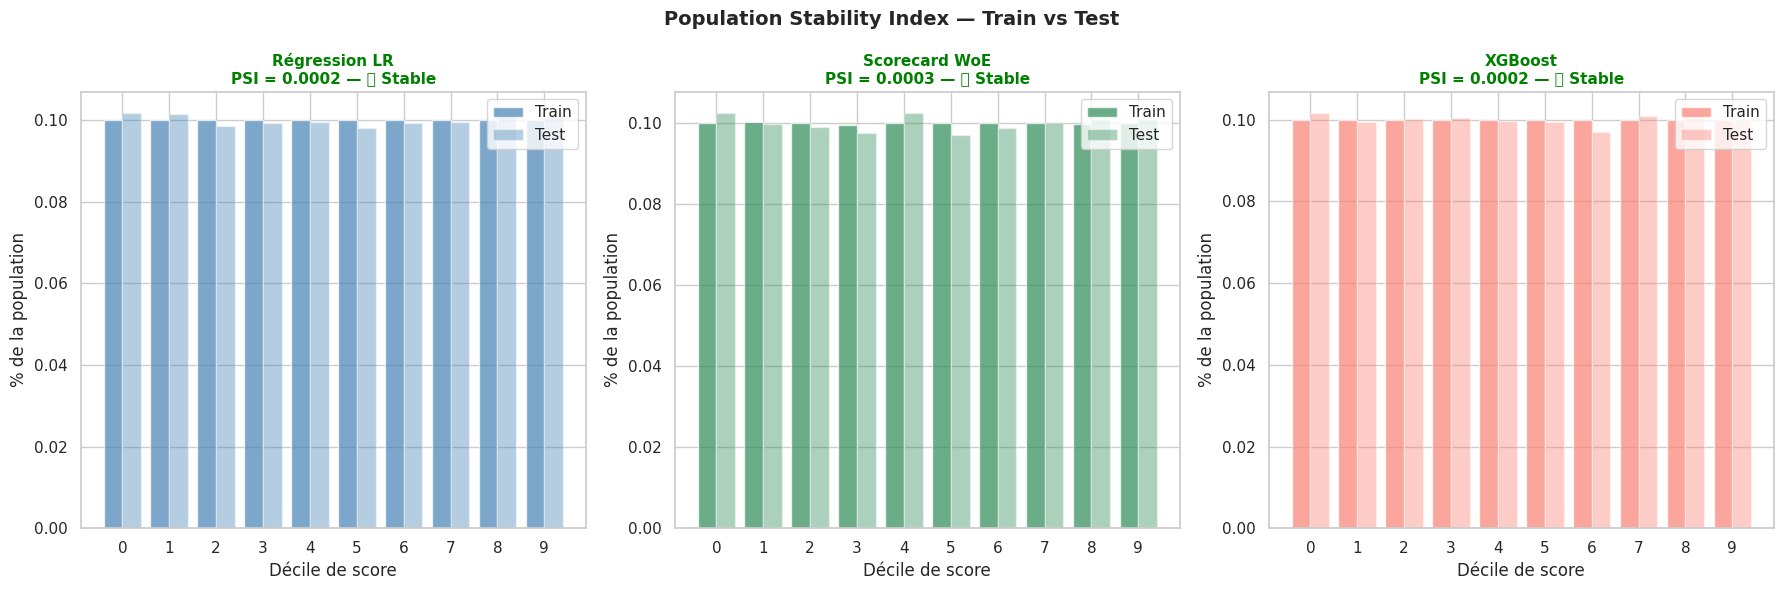

   Résumé PSI — Train vs Test
   Régression LR   PSI = 0.0002  ✅ Stable
   Scorecard WoE   PSI = 0.0003  ✅ Stable
   XGBoost         PSI = 0.0002  ✅ Stable


In [38]:
# ── Calcul PSI pour les 3 modèles ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models_psi = [
    ('Régression LR', train_scores_lr,  test_scores_lr,  'steelblue'),
    ('Scorecard WoE', train_scores_woe, test_scores_woe, 'seagreen'),
    ('XGBoost',       train_scores_xgb, test_scores_xgb, 'salmon')
]

psi_results = {}

for idx, (name, train_sc, test_sc, color) in enumerate(models_psi):

    df_psi, psi_total = calculate_psi(train_sc, test_sc)
    psi_results[name] = psi_total

    # Visualisation
    x = np.arange(len(df_psi))
    axes[idx].bar(x - 0.2, df_psi['train_pct'], 0.4,
                  label='Train', color=color, alpha=0.7)
    axes[idx].bar(x + 0.2, df_psi['test_pct'],  0.4,
                  label='Test',  color=color, alpha=0.4)

    # Couleur selon seuil PSI
    if psi_total < 0.10:
        status = '✅ Stable'
        title_color = 'green'
    elif psi_total < 0.25:
        status = '⚠️ Légère dérive'
        title_color = 'orange'
    else:
        status = '❌ Dérive significative'
        title_color = 'red'

    axes[idx].set_title(f'{name}\nPSI = {psi_total:.4f} — {status}',
                        fontweight='bold', fontsize=11, color=title_color)
    axes[idx].set_xlabel('Décile de score')
    axes[idx].set_ylabel('% de la population')
    axes[idx].legend()
    axes[idx].set_xticks(x)

plt.suptitle("Population Stability Index — Train vs Test",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('psi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Résumé PSI ────────────────────────────────────────────────────────────────
print("=" * 45)
print("   Résumé PSI — Train vs Test")
print("=" * 45)
for name, psi in psi_results.items():
    status = '✅ Stable' if psi < 0.10 else '⚠️ Surveiller' if psi < 0.25 else '❌ Dérive'
    print(f"   {name:<15} PSI = {psi:.4f}  {status}")
print("=" * 45)

## Phase 5 — Stabilité PSI

### Résultats

| Modèle | PSI | Statut |
|---|---|---|
| Régression LR | 0.0002 | ✅ Stable |
| Scorecard WoE | 0.0003 | ✅ Stable |
| XGBoost | 0.0002 | ✅ Stable |

### Interprétation

Les 3 modèles affichent des PSI quasi nuls — la distribution des scores
est parfaitement stable entre le train et le test.

Les barres train et test sont identiques pour chaque décile (~10%
de la population par décile) — aucune dérive de population détectée.

### Limite importante
Les PSI très faibles s'expliquent par le fait que le train et le test
Kaggle proviennent de la même source et de la même période.

Dans un contexte bancaire réel, le PSI serait calculé entre le dataset
d'entraînement historique et les nouveaux clients — des valeurs entre
0.05 et 0.15 seraient typiques et acceptables.

**Conclusion** : les 3 modèles sont validés sur la dimension stabilité
du backtesting IFRS 9.

In [39]:
import joblib
import os

# ── Créer le dossier models ────────────────────────────────────────────────────
os.makedirs('/content/drive/MyDrive/GiveMeSomeCredit/models', exist_ok=True)

path_models = '/content/drive/MyDrive/GiveMeSomeCredit/models/'

# ── Sauvegarder les modèles ────────────────────────────────────────────────────
joblib.dump(calibrated_lr,  path_models + 'calibrated_lr.pkl')
joblib.dump(calibrated_woe, path_models + 'calibrated_woe.pkl')
joblib.dump(calibrated_xgb, path_models + 'calibrated_xgb.pkl')

# ── Sauvegarder le scaler et les configs WoE ──────────────────────────────────
joblib.dump(scaler,      path_models + 'scaler.pkl')
joblib.dump(woe_maps,    path_models + 'woe_maps.pkl')
joblib.dump(woe_configs, path_models + 'woe_configs.pkl')

# ── Sauvegarder les métriques de backtesting ──────────────────────────────────
metrics = {
    'discrimination' : {
        'LR'  : {'AUC': auc,     'Gini': gini,     'KS': ks_stat},
        'WoE' : {'AUC': auc_woe, 'Gini': gini_woe, 'KS': ks_woe},
        'XGB' : {'AUC': auc_xgb, 'Gini': gini_xgb, 'KS': ks_xgb}
    },
    'calibration' : {
        'LR'  : {'Brier': bs_lr},
        'WoE' : {'Brier': bs_woe},
        'XGB' : {'Brier': bs_xgb}
    },
    'stability' : {
        'LR'  : {'PSI': psi_results['Régression LR']},
        'WoE' : {'PSI': psi_results['Scorecard WoE']},
        'XGB' : {'PSI': psi_results['XGBoost']}
    },
    'default_rate' : float(y_train.mean()),
    'train_size'   : len(y_train),
    'val_size'     : len(y_val)
}

joblib.dump(metrics, path_models + 'metrics.pkl')

# ── Vérification ──────────────────────────────────────────────────────────────
files = os.listdir(path_models)
print("✅ Modèles sauvegardés :")
for f in files:
    size = os.path.getsize(path_models + f) / 1024
    print(f"   {f:<30} {size:.1f} KB")

✅ Modèles sauvegardés :
   calibrated_lr.pkl              3.8 KB
   calibrated_woe.pkl             6.2 KB
   calibrated_xgb.pkl             2462.6 KB
   scaler.pkl                     1.4 KB
   woe_maps.pkl                   3.3 KB
   woe_configs.pkl                0.4 KB
   metrics.pkl                    0.6 KB
